# Beta-binomial distribution example


This notebook demonstrates the use of the beta-binomial distribution to analyze the probability of observing a certain number of successes ("good measurements") in a series of trials. It uses the `scipy.stats.betabinom` and `scipy.stats.beta` distributions to:

- Visualize the probability mass function (PMF) and cumulative distribution function (CDF) for the beta-binomial distribution.
- Calculate and plot confidence intervals for the expected number of successes.
- Show how to determine the upper threshold for the number of additional trials needed to achieve a target number of successes with a given confidence level, given the number of successes so far.

## Why use the Beta distribution?

Suppose you perform N trials, observing a certain number of successes (a) and failures (b). If you need to achieve a total of N successful outcomes, you may want to know how many additional trials are required to reach this goal with a certain confidence level, given your observed data. This is exactly the situation encountered in post-selection for quantum computing, where you need to estimate how many more shots are needed to obtain a desired number of successful post-selections.

The beta-binomial distribution is the standard way to model this situation because the beta distribution is the conjugate prior for the binomial distribution. If we assume a beta distribution as our prior for the success probability p, then after observing data (number of successes and failures), the posterior distribution of p will also be a beta. The posterior predictive distribution for the number of successes in future trials is obtained by integrating the binomial likelihood over the beta posterior for p, resulting in the beta-binomial distribution. Here's the reasoning:

- **Uncertainty in Success Probability**: The true probability of success ($p$) is unknown. The Beta distribution serves as a prior for $p$, representing our initial beliefs before seeing any data.
- **Bayesian Updating**: After observing data (number of successes and failures), we update our beliefs about $p$ using the Beta posterior.
- **Marginalizing Over $p$**: The beta-binomial distribution arises when we account for both the randomness of the trials and our uncertainty about $p$ by integrating (marginalizing) over the Beta posterior.
- **Interpretation**: The beta-binomial models the distribution of the number of successes in a fixed number of trials, accounting for both observed data and prior uncertainty in the success probability.

**Note:**
If we have no prior knowledge about $p$, we use a uniform Beta prior with parameters $a=1$ and $b=1$. This represents complete uncertainty about the probability of success before observing any data. This is why you see lots of `+1` in the code when calculating the parameters for the beta distribution.




In [1]:
import numpy as np
from scipy.stats import betabinom, beta, binom
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

In [2]:
n, a = 1000, 975  # 1000 trials, 975 successes

conf_lim_1tail = 0.99  # confidence limit for 1-tailed test (e.g., upper bound on expected successes)
conf_lim_2tail = (
    1 - (1 - conf_lim_1tail) * 2
)  # confidence limit for 2-tailed test (e.g., confidence interval around the median)

b = n - a  # calculate number of failures
n, a, b, conf_lim_1tail, conf_lim_2tail

(1000, 975, 25, 0.99, 0.98)

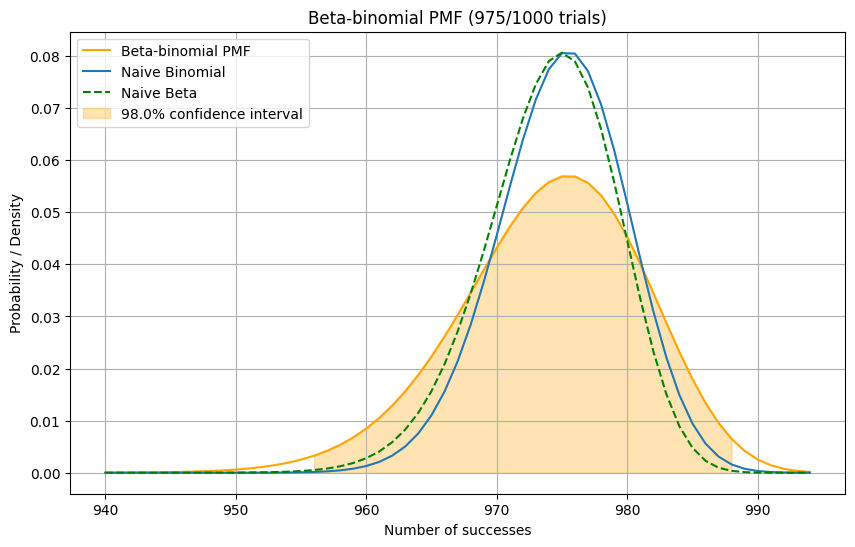

In [3]:
# Show the pdf of the expected number of good measurements for a new trial, given the number of good measurements so far (a) and the number of bad measurements (b).
# Also the 2-tail confidence interval (centered around the median)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_width = betabinom.interval(0.9999, n, a + 1, b + 1)
x = np.arange(*plot_width)
pmf = betabinom.pmf(x, n, a + 1, b + 1)
ax.plot(x, pmf, label="Beta-binomial PMF", color="orange")
conf_int = betabinom.interval(conf_lim_2tail, n, a + 1, b + 1)
# plot beta and binomial dists for info if necessary
ax.plot(x, binom.pmf(x, n, a / (a + b)), label="Naive Binomial")
ax.plot(x, beta.pdf(x / n, a + 1, b + 1) / n, label="Naive Beta", color="g", linestyle="--")

# Shade area under Beta-binomial PMF within confidence interval
mask = (x >= conf_int[0]) & (x <= conf_int[1])
ax.fill_between(x[mask], pmf[mask], color="orange", alpha=0.3, label=f"{conf_lim_2tail * 100:.1f}% confidence interval")

# ax.vlines(
#     conf_int,
#     0,
#     max(pmf),
#     colors="r",
#     linestyles="-.",
#     # label=f"Expectation limit\n({conf_lim_2tail * 100:2.0f}% confidence)",
# )
ax.set_xlabel("Number of successes")
ax.set_ylabel("Probability / Density")
ax.set_title(f"Beta-binomial PMF ({a}/{n} trials)")
ax.grid()
ax.legend()

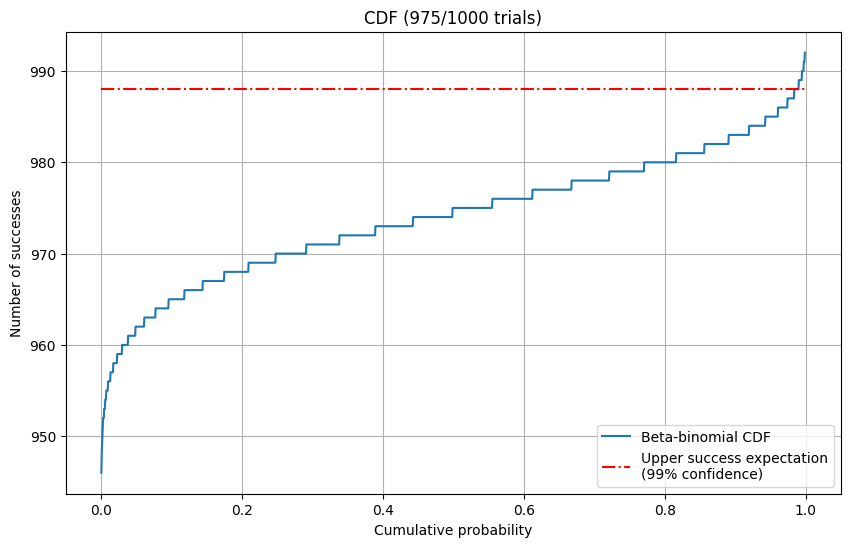

In [4]:
# Alternatively, plot the cdf of a new trial showing the 1-tailed threshold
step = 0.0005
x = np.arange(0, 1, step)
x = x[1:-1]
plt.figure(figsize=(10, 6))
plt.plot(x, betabinom.ppf(x, n, a + 1, b + 1), label="Beta-binomial CDF")
upper_expectation = betabinom.ppf(conf_lim_1tail, n, a + 1, b + 1)
plt.hlines(
    upper_expectation,
    0,
    1,
    colors="r",
    linestyles="-.",
    label=f"Upper success expectation\n({conf_lim_1tail * 100:2.0f}% confidence)",
)
plt.xlabel("Cumulative probability")
plt.ylabel("Number of successes")
plt.title(f"CDF ({a}/{n} trials)")
plt.grid()
plt.legend(loc="lower right")

In [5]:
upper_expectation, conf_int

(np.float64(988.0), (np.float64(956.0), np.float64(988.0)))

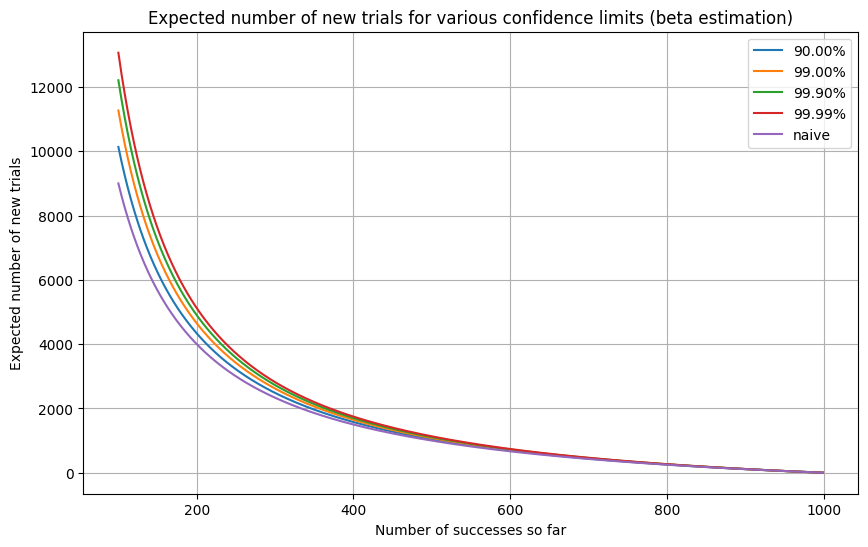

In [6]:
# Calculate the upper threshold of expected number of new trials
# needed for each confidence limit given the number of good measurements so far
# Use Beta posterior with prior a=1, b=1, so parameters are n_passes+1, n_failures+1
def calc_upper_conf(n_trials, n_passes, conf_lim_1tail):
    n_failures = n_trials - n_passes
    lower_passrate = beta.ppf(1 - conf_lim_1tail, n_passes + 1, n_failures + 1)
    exp_trials = n_failures / lower_passrate
    return exp_trials


x = np.arange(100, n)
plt.figure(figsize=(10, 6))
for conf_lim in [0.9, 0.99, 0.999, 0.9999]:
    plt.plot(x, calc_upper_conf(n, x, conf_lim), label=f"{conf_lim * 100:2.2f}%")
# naive expectation of number of new trials needed to get n passes, given x passes so far:
# this is just the expected number of failures divided by the pass rate, without accounting for uncertainty in the pass rate or the binomial response.
naive = (n - x) / (x / n)
plt.plot(x, naive, label="naive")
plt.xlabel("Number of successes so far")
plt.ylabel("Expected number of new trials")
# plt.yscale("log")
plt.title("Expected number of new trials for various confidence limits (beta estimation)")
plt.grid()
plt.legend()

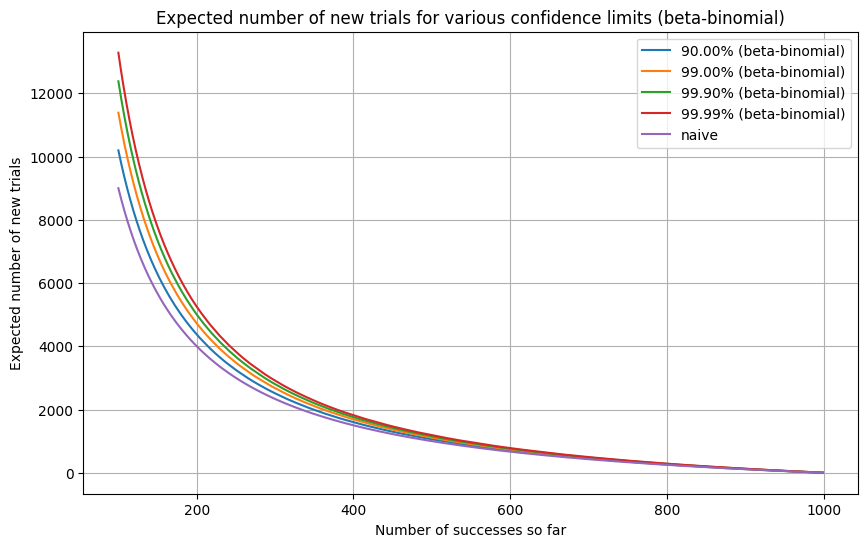

In [7]:
# Calculate the upper threshold of expected number of new trials
# needed for each confidence limit given the number of good measurements so far
# Use Beta posterior with prior a=1, b=1, so parameters are n_passes+1, n_failures+1


def calc_upper_conf_betabinom(n_total, n_passes, conf_lim_1tail):
    """
    For each number of successes so far (n_passes), find the minimum number of additional trials
    needed so that the probability of reaching n_total successes is at least conf_lim_1tail.
    Uses the beta posterior lower bound as a guess, then root-finding for efficiency and robustness.
    """
    n_failures = n_total - n_passes
    if n_passes >= n_total:
        return 0
    alpha = n_passes + 1
    beta_param = n_failures + 1
    required_successes = n_failures
    # Step 1: Lower bound for pass rate at confidence level
    lower_passrate = beta.ppf(1 - conf_lim_1tail, alpha, beta_param)

    # Step 1: Define function for root finding
    def func(k):
        k = int(np.ceil(k))
        if k < 0:
            return -conf_lim_1tail
        prob = 1 - betabinom.cdf(required_successes - 1, k, alpha, beta_param)
        return prob - conf_lim_1tail

    # Step 2: Estimate minimum number of additional trials needed
    k_max = int(np.ceil(n_failures / lower_passrate)) if lower_passrate > 0 else n_failures
    # Step 4: Use root finding. Find tue upper bound by , starting near the guess
    while func(k_max) < 0:
        k_max *= 2

    sol = root_scalar(func, bracket=[0, k_max], method="bisect", xtol=1)
    return int(np.ceil(sol.root))


x = np.arange(100, n)
plt.figure(figsize=(10, 6))
for conf_lim in [0.9, 0.99, 0.999, 0.9999]:
    y = [calc_upper_conf_betabinom(n, xi, conf_lim) for xi in x]
    plt.plot(x, y, label=f"{conf_lim * 100:2.2f}% (beta-binomial)")
# naive expectation of number of new trials needed to get n passes, given x passes so far:
naive = (n - x) / (x / n)
plt.plot(x, naive, label="naive")
plt.xlabel("Number of successes so far")
plt.ylabel("Expected number of new trials")
# plt.yscale("log")
plt.title("Expected number of new trials for various confidence limits (beta-binomial)")
plt.grid()
plt.legend()

n_passes | beta | beta-binomial | diff
    100 | 13065.14 |      13286.00 |  220.86
    150 | 7606.88 |       7772.00 |  165.12
    200 | 5120.72 |       5253.00 |  132.28
    300 | 2818.02 |       2912.00 |   93.98
    500 | 1132.65 |       1187.00 |   54.35
    900 |  116.21 |        128.00 |   11.79


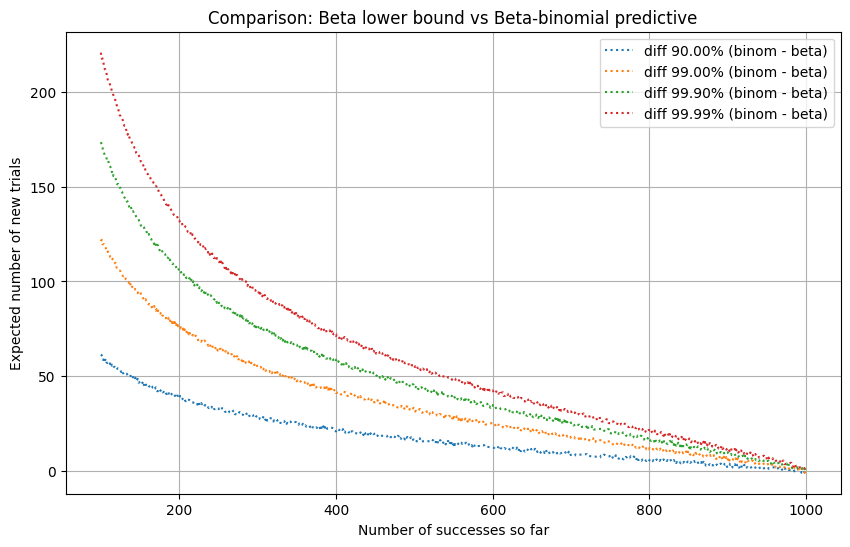

In [10]:
# Compare the two methods directly and plot their difference
x = np.arange(100, n)
plt.figure(figsize=(10, 6))
for conf_lim in [0.9, 0.99, 0.999, 0.9999]:
    y_beta = calc_upper_conf(n, x, conf_lim)
    y_betabinom = [calc_upper_conf_betabinom(n, xi, conf_lim) for xi in x]
    # plt.plot(x, y_betabinom, label=f"{conf_lim * 100:2.2f}% (beta-binomial)")
    # plt.plot(x, y_beta, '--', label=f"{conf_lim * 100:2.2f}% (beta lower bound)")
    plt.plot(x, np.array(y_betabinom) - np.array(y_beta), ":", label=f"diff {conf_lim * 100:2.2f}% (binom - beta)")
plt.xlabel("Number of successes so far")
plt.ylabel("Expected number of new trials")
plt.title("Comparison: Beta lower bound vs Beta-binomial predictive")
plt.grid()
plt.legend()

# Print values for small n_passes and high confidence
print("n_passes | beta | beta-binomial | diff")
for xi in [100, 150, 200, 300, 500, 900]:
    beta_val = calc_upper_conf(n, xi, 0.9999)
    betabinom_val = calc_upper_conf_betabinom(n, xi, 0.9999)
    print(f"{xi:7d} | {beta_val:7.2f} | {betabinom_val:13.2f} | {betabinom_val - beta_val:7.2f}")